# 🔍 Notatbok 03 — Avhør av mistenkte

**Lokale forklaringer og kontrafaktiske eksempler — hvorfor DENNE prediksjonen for DENNE personen.**

Vi har undersøkt åstedet (globale forklaringer). Nå zoomer vi inn på
**spesifikke mistenkte**. En lokal forklaring svarer: *hvorfor ga modellen
akkurat denne prediksjonen for akkurat denne personen?*

### Verktøy i denne notatboken

| Verktøy | Spørsmål |
|---------|----------|
| SHAP waterfall | Hvordan dyttet hver egenskap denne prediksjonen opp eller ned? |
| LIME | Hva sier en lokal lineær tilnærming? |
| DiCE-kontrafaktiske | Hva er den minste endringen som snur beslutningen? |

## 0. Oppsett

In [893]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn shap lime dice-ml ipywidgets

In [894]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import dice_ml
import pickle
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
print("✅ Alle importer lastet inn.")

✅ Alle importer lastet inn.


In [895]:
load_path = "nb01_artifacts.pkl" if IN_COLAB else "../data/nb01_artifacts.pkl"
with open(load_path, "rb") as f:
    arts = pickle.load(f)
model = arts["model"]
X_train, X_test = arts["X_train"], arts["X_test"]
y_train, y_test = arts["y_train"], arts["y_test"]
feature_cols = arts["feature_cols"]
df = arts["df"]
df_model = arts["df_model"]
X, y = arts["X"], arts["y"]
print("✅ Artefakter lastet inn.")

✅ Artefakter lastet inn.


## 1. SHAP waterfall — Karis sak

Et **waterfall-plott** starter ved **basisverdien** (gjennomsnittlig modellutgang)
og viser hvordan hver egenskap dytter prediksjonen opp (mot godkjent) eller ned
(mot avslått). Det er det mest presise lokale forklaringsverktøyet vi har.

Tenk på det som en spesifisert kvittering: hvert bidrag fra en egenskap er listet opp,
og de summerer seg til den endelige prediksjonen.

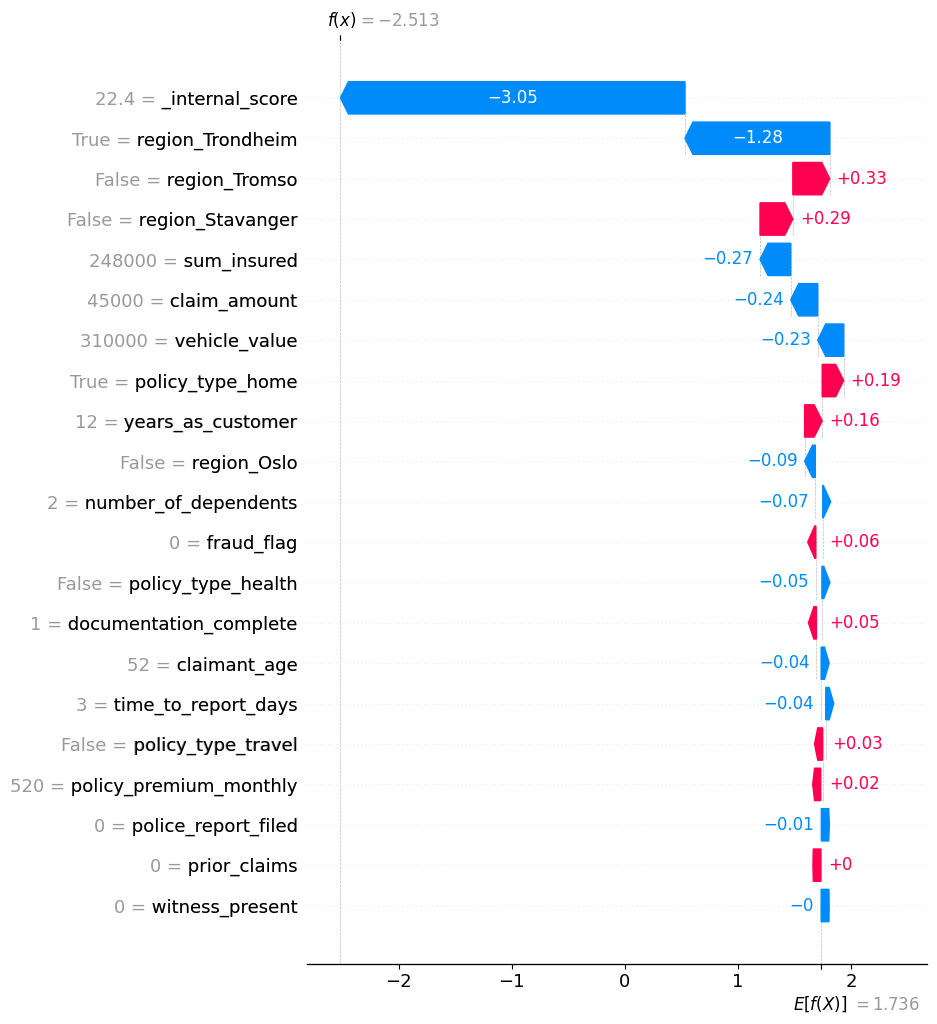

In [896]:
explainer = shap.TreeExplainer(model)
kari_shap = explainer(X.loc[[42]])
shap.plots.waterfall(kari_shap[0], max_display=len(feature_cols))

### Diskusjon

Hva avslører waterfall-plottet?
- Hvilke egenskaper dytter Kari **mot avslag**?
- Hvilke egenskaper dytter henne **mot godkjenning**?
- Stemmer forklaringen med hypotesen din fra Notatbok 01?

## 1b. Eriks sak — den andre mistenkte

Husker du Erik fra Notatbok 01? Ung, kort historikk, to tidligere krav, høyt
kravsbeløp — og likevel **godkjent**. La oss se hva SHAP sier om *hans* sak.

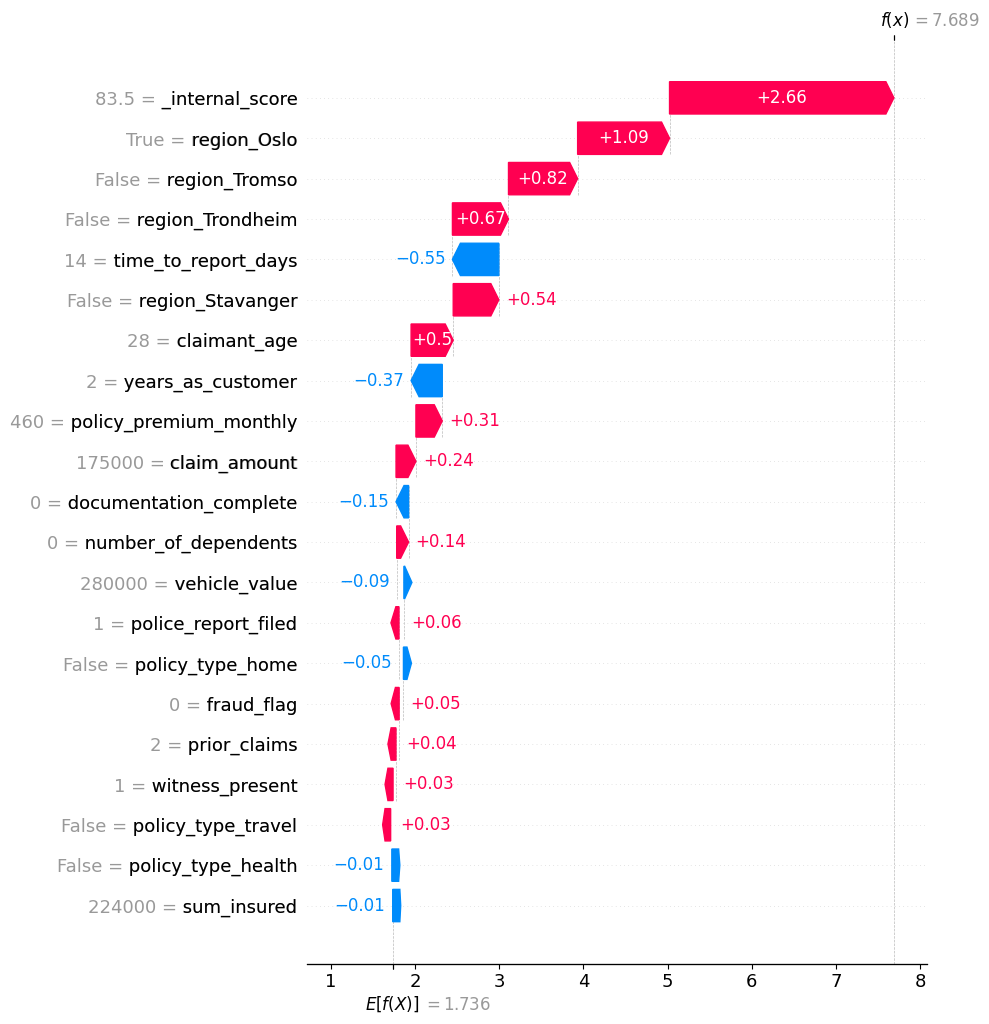

In [897]:
erik_shap = explainer(X.loc[[7]])
shap.plots.waterfall(erik_shap[0], max_display=len(feature_cols))

### Kari vs Erik — sammenlign waterfallene

Se på `claim_amount` i begge waterfallene:
- Hos Kari: dytter den mot **avslag** (eller er nøytral)
- Hos Erik: dytter den mot **godkjenning** — men globalt så vi at høyere beløp
  burde bety *lavere* godkjenningssannsynlighet!

Hvorfor behandler modellen **samme egenskap** helt forskjellig for disse to?

## 2. LIME — En second opinion

**LIME** (Local Interpretable Model-agnostic Explanations) bruker en annen
tilnærming: den genererer forstyrrede datapunkter *nær* instansen, henter modellens
prediksjoner for disse, og tilpasser en **enkel lineær modell** for å tilnærme
beslutningsgrensen lokalt.

Annen filosofi enn SHAP — la oss se om de er enige.

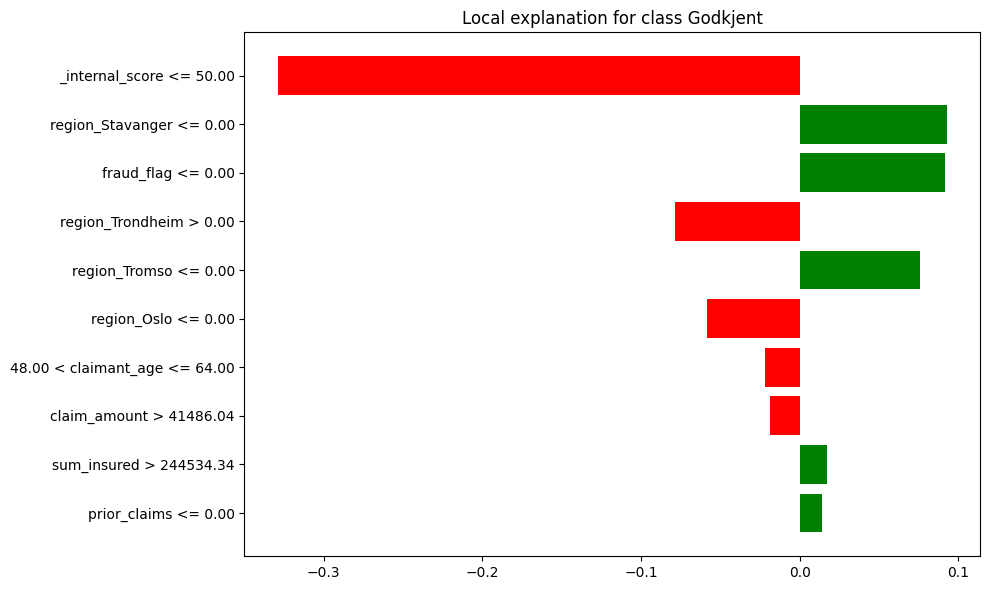

In [898]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    class_names=["Avslått", "Godkjent"],
    mode="classification"
)

kari_lime = lime_explainer.explain_instance(
    X.loc[42].values,
    model.predict_proba,
    num_features=10
)
kari_lime.as_pyplot_figure()

plt.tight_layout()
plt.show()

### SHAP vs LIME — er de enige?

Sammenlign SHAP waterfall-plottet og LIME-forklaringen:
- Er de enige om de **viktigste egenskapene**?
- Er de enige om **retningen** (positiv/negativ)?
- Hvor er de **uenige**?

## 3. Finne uenighet

La oss systematisk lete etter en sak der SHAP og LIME **er uenige** om den
viktigste egenskapen. Dette skjer oftere enn du kanskje tror.

UENIGHET ved indeks 4622!
  SHAP topp-egenskap: _internal_score
  LIME topp-egenskap: region_Stavanger

SHAP waterfall:


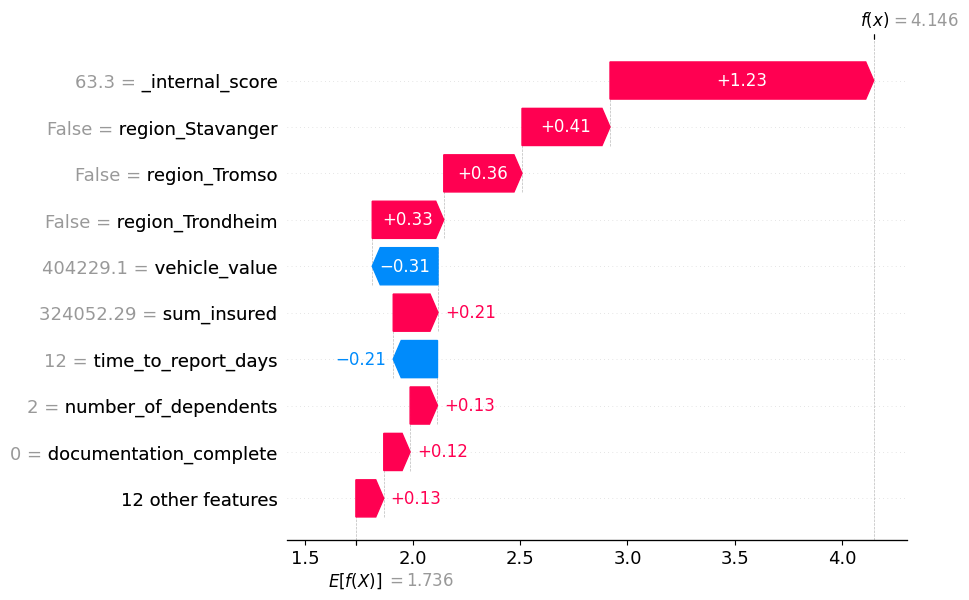


LIME-forklaring:


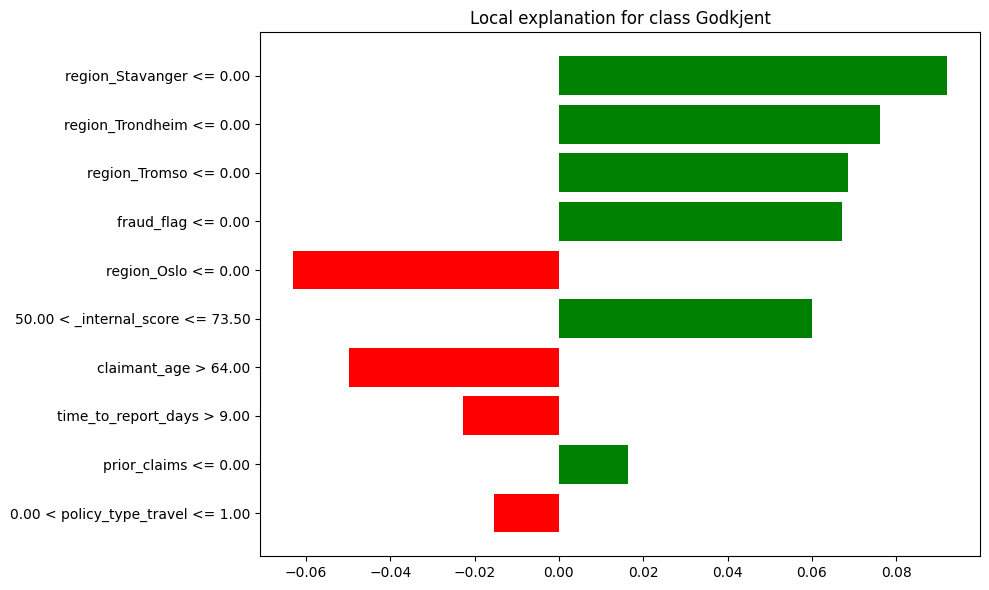

In [902]:
# Finn en sak der SHAP og LIME er uenige om #1-egenskapen
np.random.seed(42)
sample_indices = X_test.index[:200].tolist()

for idx in sample_indices:
    # SHAP topp-egenskap
    sv = explainer(X.loc[[idx]])
    shap_top = feature_cols[np.argmax(np.abs(sv.values[0]))]

    # LIME topp-egenskap
    lime_exp = lime_explainer.explain_instance(
        X.loc[idx].values, model.predict_proba, num_features=10
    )
    # LIME returns rules like "78.40 < claim_amount <= 100.00"
    # Match against known feature names to extract the actual feature
    lime_rule = lime_exp.as_list()[0][0]
    lime_top = next((f for f in feature_cols if f in lime_rule), lime_rule)

    if shap_top != lime_top:
        print(f"UENIGHET ved indeks {idx}!")
        print(f"  SHAP topp-egenskap: {shap_top}")
        print(f"  LIME topp-egenskap: {lime_top}")
        print(f"\nSHAP waterfall:")
        shap.plots.waterfall(sv[0])
        print(f"\nLIME-forklaring:")
        lime_exp.as_pyplot_figure()
        plt.tight_layout()
        plt.show()
        break

else:    print("Ingen uenighet funnet i utvalget — SHAP og LIME er enige om topp-egenskapen for disse sakene.")

### Hvorfor er de uenige?

- **SHAP** bruker eksakt spillteoretisk allokering — den vurderer alle mulige
  koalisjoner av egenskaper.
- **LIME** bruker lokal lineær tilnærming med tilfeldige forstyrrelser — den
  sampler nærliggende punkter og tilpasser en enkel modell.

Forskjellige antakelser → forskjellige svar. **Ingen av dem er «feil»** i seg selv,
men dette bør gjøre deg forsiktig med å stole blindt på én enkelt metode.

## 4. Kontrafaktiske forklaringer med DiCE

I stedet for å spørre *«hvorfor ble dette avslått?»*, spør kontrafaktiske forklaringer:
**«Hva er den minste endringen som ville snudd beslutningen til godkjent?»**

Dette er ekstremt intuitivt for interessenter: «Hvis Kari hadde X i stedet for Y,
ville hun blitt godkjent.»

In [900]:
# Sett opp DiCE — konverter alle egenskaper til float for kompatibilitet
df_dice = df_model.copy()
for col in df_dice.columns:
    if col == "approved":
        continue
    df_dice[col] = pd.to_numeric(df_dice[col], errors="coerce").astype(float)

# Workaround: DiCE sender strengverdier til pandas 2.x som krever eksakt dtype
# Guard mot dobbel patching (forhindrer uendelig rekursjon ved re-kjøring)
if not getattr(pd.DataFrame._set_value, "_patched", False):
    _orig_set_value = pd.DataFrame._set_value
    def _safe_set_value(self, index, col, value, takeable=False):
        if isinstance(value, str):
            try:
                value = float(value)
            except ValueError:
                pass
        return _orig_set_value(self, index, col, value, takeable=takeable)
    _safe_set_value._patched = True
    pd.DataFrame._set_value = _safe_set_value

dice_data = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=[c for c in feature_cols if df_dice[c].nunique() > 10],
    outcome_name="approved"
)
dice_model = dice_ml.Model(model=model, backend="sklearn")
dice_exp = dice_ml.Dice(dice_data, dice_model, method="random")

# Generer kontrafaktiske eksempler for Kari
query = X.loc[[42]].copy()
for col in query.columns:
    query[col] = pd.to_numeric(query[col], errors="coerce").astype(float)
kari_cf = dice_exp.generate_counterfactuals(
    query, total_CFs=5, desired_class="opposite"
)
kari_cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00, 13.36it/s]

Query instance (original outcome : 0)


,claimant_age,years_as_customer,prior_claims,claim_amount,vehicle_value,sum_insured,police_report_filed,time_to_report_days,documentation_complete,witness_present,...,fraud_flag,_internal_score,region_Oslo,region_Stavanger,region_Tromso,region_Trondheim,policy_type_health,policy_type_home,policy_type_travel,approved
0,52.0,12.0,0.0,45000.0,310000.0,248000.0,0.0,3.0,1.0,0.0,...,0.0,22.4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0



Diverse Counterfactual set (new outcome: 1)


,claimant_age,years_as_customer,prior_claims,claim_amount,vehicle_value,sum_insured,police_report_filed,time_to_report_days,documentation_complete,witness_present,...,fraud_flag,_internal_score,region_Oslo,region_Stavanger,region_Tromso,region_Trondheim,policy_type_health,policy_type_home,policy_type_travel,approved
0,-,-,-,-,-,-,-,-,-,-,...,-,80.7,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-,14.8,-,-,...,-,-,1.0,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-,-,-,-,...,-,88.6,-,-,-,-,-,-,-,1.0
3,-,-,-,-,-,-,-,20.2,-,-,...,-,81.5,-,-,-,-,-,-,-,1.0
4,-,-,-,-,-,-,-,-,-,-,...,-,41.0,-,-,-,-,-,-,-,1.0


## Øvelse 4: Sammenlign Kari og Erik

Kjør LIME og DiCE på **Erik (rad 7)** og sammenlign med Karis forklaringer.
Hvorfor hjelper høyt kravsbeløp Erik, men skader Kari?

In [901]:
# ØVELSE: Sammenlign Kari og Erik
#
# Steg 1: LIME-forklaring for Erik
# erik_lime = lime_explainer.explain_instance(
#     X.loc[7].values, model.predict_proba, num_features=10
# )
# erik_lime.as_pyplot_figure()
# plt.tight_layout()
# plt.show()
#
# Steg 2: DiCE-kontrafaktisk for Erik (hva ville snudd ham til avslag?)
# query_erik = X.loc[[7]].copy()
# for col in query_erik.columns:
#     query_erik[col] = pd.to_numeric(query_erik[col], errors="coerce").astype(float)
# erik_cf = dice_exp.generate_counterfactuals(
#     query_erik, total_CFs=3, desired_class="opposite"

# )# - Region kan spille en rolle fordi:

# erik_cf.visualize_as_dataframe(show_only_changes=True)# - claim_amount påvirker Kari og Erik forskjellig fordi:

## DINE OBSERVASJONER:
# Steg 3: Sammenlign SHAP, LIME og DiCE for begge

## Viktige lærdommer

| Metode | Spørsmål | Fordeler | Ulemper |
|--------|----------|----------|---------|
| SHAP waterfall | Hvordan kombinerte egenskapene seg for DENNE prediksjonen? | Eksakt, additiv, teoretisk fundert | Treg for ikke-tremodeller |
| LIME | Hva er den lokale lineære tilnærmingen? | Modellagnostisk, intuitivt resultat | Ustabil mellom kjøringer |
| DiCE | Hvilken endring ville snudd beslutningen? | Handlingsbar, interessentvennlig | Flere gyldige kontrafaktiske |

> **Globalt** gir deg landskapet. **Lokalt** forteller historien om **ÉN** beslutning.
> Men når to beslutninger forteller **motsatte** historier om samme egenskap —
> da må vi grave dypere.

👉 **Neste:** [Notatbok 04 — Når forklaringer lyver](04_when_explanations_lie.ipynb)

Erik så forskjellig? Neste notatbok vil ryste tilliten din...*
*Kan vi stole på disse forklaringene? Og hvorfor behandler modellen Kari og